In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
# Graph aesthetics settings
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
large = 20; medium = 16; small = 12
colors = ['#66bb6a', '#558ed5', '#dd6a63', '#dcd0ff', '#ffa726', '#8c5eff', '#f44336', '#00bcd4', '#ffc107', '#9c27b0']
text_color = "#404040"

params = {'axes.titlesize': medium,
          'legend.fontsize': small,
          'figure.figsize': (16, 16),
          'axes.labelsize': small,
          'axes.linewidth': 2,
          'xtick.labelsize': small,
          'xtick.color': text_color,
          'ytick.color': text_color,
          'ytick.labelsize': small,
          'axes.edgecolor': text_color,
          'figure.titlesize': small,
          'axes.prop_cycle': cycler(color=colors),
          'axes.titlecolor': text_color,
          'axes.labelcolor': text_color,
         }

plt.rcParams.update(params)

In [3]:
# Import necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

from neurodiffeq import diff
from neurodiffeq.conditions import IVP, DirichletBVP, DirichletBVP2D
from neurodiffeq.solvers import Solver1D, Solver2D
from neurodiffeq.networks import FCNN, SinActv
from neurodiffeq.monitors import Monitor1D
from neurodiffeq.generators import Generator1D, Generator2D

C:\Users\laksh\anaconda3\envs\torch\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
def plot_loss(solver):
    history = solver.metrics_history
    plt.figure(figsize=(8,5))
    plt.plot(np.log10(history['train_loss']), label = 'Train')
    
    # Add axis labels, title and legend for clarity
    plt.title('Loss plot')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_results(solver):
    history = solver.metrics_history
    t_vals = np.linspace(solver.t_min, solver.t_max, 1000)
    u_pred = solver.get_solution()(t_vals, to_numpy=True)
    plt.figure(figsize=(8,5))
    #plt.plot(t_vals, [np.sin(i) for i in t_vals], c = colors[1])
    plt.plot(t_vals, u_pred, '--', c = colors[0])
    
    # Add axis labels and title for clarity
    plt.title(f'Neural Network approximation at {len(history["train_loss"])} epochs.')
    plt.xlabel('u')
    plt.ylabel('t')
    plt.grid(True)
    plt.show()

Training Progress:   0%|                                                                      | 0/5000 [00:00<…

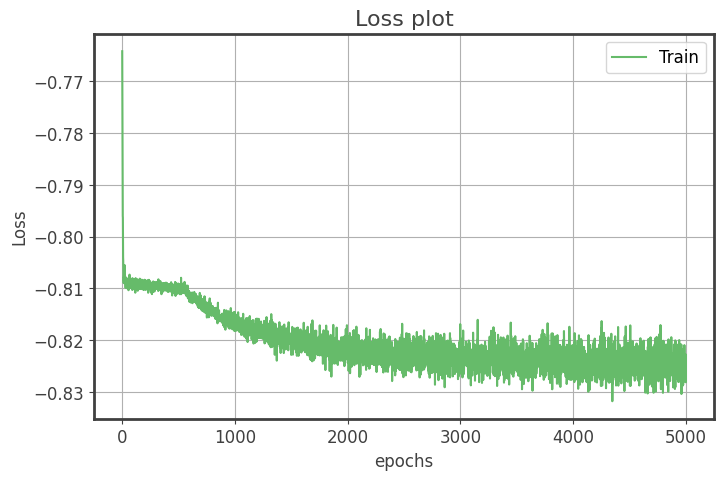

In [5]:
k = 2.0
def he(x, y):
    return np.sin(np.pi*x)*np.exp(-np.pi**2*k*y)
def heat_equation(u, x, t):
    return [diff(u, t) - k*diff(u, x, order=2)]
init_val = [
    DirichletBVP2D(
        x_min=0, x_min_val=lambda y: 0,
        x_max=1, x_max_val=lambda y: 0,                   
        y_min=0, y_min_val=lambda x: torch.sin(np.pi*x),                   
        y_max=1, y_max_val=lambda x: 0,                   
    )
]
nets = [FCNN(n_input_units=2, n_output_units=1, hidden_units=[64, 64])]
xy_min = (0, 0)
xy_max = (1, 1)
train_g = Generator2D((32, 32), xy_min, xy_max , method='equally-spaced-noisy') 
valid_g = Generator2D((8, 8), xy_min, xy_max , method='equally-spaced')
optimizer = torch.optim.Adam([p for net in nets for p in net.parameters()],lr = 1e-3)
# Set up the solver
solver = Solver2D(pde_system = heat_equation, 
                  conditions = init_val, 
                  xy_min=xy_min, 
                  xy_max=xy_max, 
                  nets=nets,
                  train_generator=train_g, 
                  valid_generator=valid_g,
                  n_batches_valid = 0,
                  optimizer = optimizer)
solver.fit(max_epochs=5000)
plot_loss(solver)

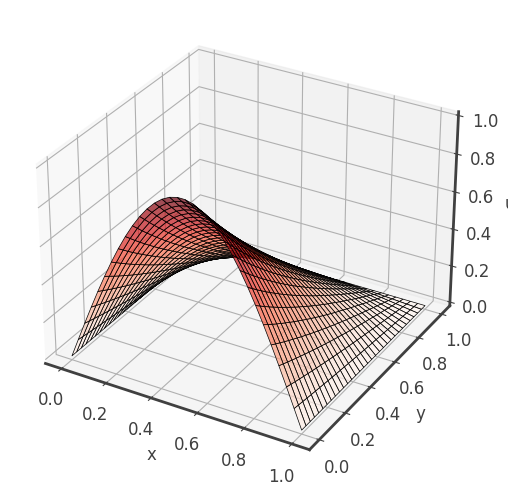

In [6]:
x, y = np.meshgrid(np.linspace(0, 1, 32), np.linspace(0, 1, 32))
u_pred = solver.get_solution(best=True)(x, y, to_numpy = True)
u_true = he(x, y)
# Create a 3D plot of the solution obtained halfway through the training
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, u_pred,cmap=plt.cm.Reds, edgecolors='k', linewidths=0.5, alpha= 0.7)
# ax.plot_surface(x, y, u_true,cmap=plt.cm.Greens, edgecolors='k', linewidths=0.5, alpha = 0.7)
# ax.plot_surface(x, y, u_true-u_pred,cmap=plt.cm.Greens, edgecolors='k', linewidths=0.5, alpha= 0.7)
ax.set_xlabel('X')
ax.set_ylabel('T')
ax.set_zlabel('Residuals^2')
#ax.set_title('Squared residuals of the heat equation halfway through training')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
# ax.set_title('Estimated PINNs solution')
plt.tight_layout()
plt.show()

In [7]:
res = solver.get_residuals(x, y, to_numpy=True)

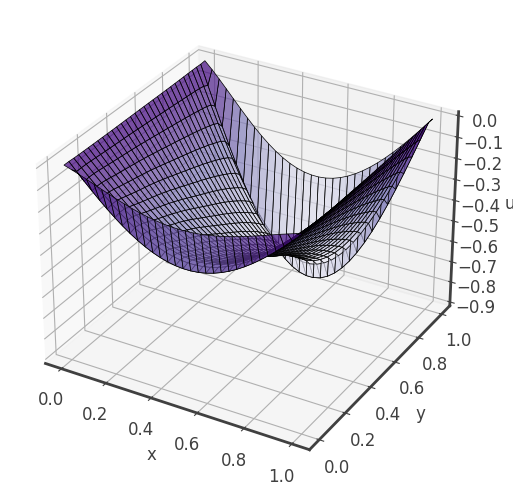

In [8]:
# Create a 3D plot of the solution obtained halfway through the training
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(x, y, u_pred,cmap=plt.cm.Reds, edgecolors='k', linewidths=0.5, alpha= 0.7)
# ax.plot_surface(x, y, u_true,cmap=plt.cm.Greens, edgecolors='k', linewidths=0.5, alpha = 0.7)
ax.plot_surface(x, y, res,cmap=plt.cm.Purples, edgecolors='k', linewidths=0.5, alpha= 0.7)
ax.set_xlabel('X')
ax.set_ylabel('T')
ax.set_zlabel('Residuals^2')
#ax.set_title('Squared residuals of the heat equation halfway through training')


ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
# ax.set_title('Estimated PINNs solution')
plt.tight_layout()
plt.show()